1. Import libraries and load data

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [19]:
# Load your cleaned order items data
order_items = pd.read_csv("cleaned_order_items.csv")

# Load products data
products = pd.read_csv("cleaned_products.csv")

# Display data
print(order_items.head())
print(products.head())

  order_item_id order_id  quantity product_id  unit_price  discount(%)  \
0      OI000001   O00001         1     P28355      7020.0         6.54   
1      OI000002   O00002         1     P04408      7590.0        20.56   
2      OI000003   O00002         2     P14887     14360.0        24.67   
3      OI000004   O00003         2     P02014      1530.0        12.06   
4      OI000005   O00003         1     P27255      1560.0        10.51   

   shipping_cost  
0         713.72  
1        1212.02  
2        1478.39  
3         155.12  
4         188.03  
  product_id   Category_name    sub_category_name  product_weight_g  \
0     P00001       perfumery           Fragrances               225   
1     P00002             art  General Merchandise              1000   
2     P00003  sports_leisure  General Merchandise               154   
3     P00004            baby         Collectibles               371   
4     P00005      housewares        Novelty Items               625   

            br

2. Merge the datasets

We need product information such as cost_price and selling_price.

In [20]:
df = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150000, 14)


,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,Category_name,sub_category_name,product_weight_g,brand,cost_price,selling_price,stock_availability
0,OI000001,O00001,1,P28355,7020.0,6.54,713.72,sports_leisure,Novelty Items,1325,Generic Indian,5330.0,7020.0,In Stock
1,OI000002,O00002,1,P04408,7590.0,20.56,1212.02,sports_leisure,Novelty Items,24700,Generic Indian,6190.0,7590.0,In Stock
2,OI000003,O00002,2,P14887,14360.0,24.67,1478.39,health_beauty,Gifts,400,Generic Indian,11720.0,14360.0,In Stock
3,OI000004,O00003,2,P02014,1530.0,12.06,155.12,garden_tools,General Merchandise,5400,Generic Indian,1300.0,1530.0,In Stock
4,OI000005,O00003,1,P27255,1560.0,10.51,188.03,toys,Collectibles,650,Generic Indian,1300.0,1560.0,In Stock


3. Check columns

In [21]:
print(df.columns.tolist())

['order_item_id', 'order_id', 'quantity', 'product_id', 'unit_price', 'discount(%)', 'shipping_cost', 'Category_name', 'sub_category_name', 'product_weight_g', 'brand', 'cost_price', 'selling_price', 'stock_availability']


4. Feature Engineering
Create Revenue

In [22]:
df["revenue"] = df["unit_price"] * df["quantity"]

Create Discount Amount

In [23]:
df["discount_amount"] = (
    df["unit_price"] *
    df["quantity"] *
    df["discount(%)"] / 100
)

Create Profit

In [24]:
df["profit"] = (
    (df["selling_price"] - df["cost_price"])
    * df["quantity"]
)

Create Shipping Revenue/Cost per item

In [25]:
df["total_shipping_cost"] = (
    df["shipping_cost"] * df["quantity"]
)

In [26]:
df[
    [
        "unit_price",
        "quantity",
        "discount(%)",
        "revenue",
        "discount_amount",
        "profit",
        "total_shipping_cost"
    ]
].head()

,unit_price,quantity,discount(%),revenue,discount_amount,profit,total_shipping_cost
0,7020.0,1,6.54,7020.0,459.108,1690.0,713.72
1,7590.0,1,20.56,7590.0,1560.504,1400.0,1212.02
2,14360.0,2,24.67,28720.0,7085.224,5280.0,2956.78
3,1530.0,2,12.06,3060.0,369.036,460.0,310.24
4,1560.0,1,10.51,1560.0,163.956,260.0,188.03


5. Remove invalid values

In [27]:
df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(
    subset=[
        "revenue",
        "unit_price",
        "quantity",
        "shipping_cost",
        "cost_price",
        "selling_price"
    ]
)

print("Rows after cleaning:", len(df))

Rows after cleaning: 150000


6. Define Target and Features

For this regression model:

Target = Revenue

In [28]:
target = "revenue"

features = [
    "unit_price",
    "quantity",
    "discount(%)",
    "shipping_cost",
    "product_weight_g",
    "cost_price",
    "selling_price",
    "stock_availability",
    "Category_name",
    "sub_category_name",
    "brand"
]

X = df[features]
y = df[target]

print("Features:", X.columns.tolist())
print("Target:", target)

Features: ['unit_price', 'quantity', 'discount(%)', 'shipping_cost', 'product_weight_g', 'cost_price', 'selling_price', 'stock_availability', 'Category_name', 'sub_category_name', 'brand']
Target: revenue


7. Train / Validation / Test Split

We will use:

70% Training + 15% Validation + 15% Test

First separate 70% training and 30% temporary data:

In [29]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

Then split the temporary data equally:

In [30]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [31]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (105000, 11)
Validation: (22500, 11)
Testing: (22500, 11)


8. Identify numerical and categorical features

In [32]:
# Numerical features
numeric_features = [
    "unit_price",
    "quantity",
    "discount(%)",
    "shipping_cost",
    "product_weight_g",
    "cost_price",
    "selling_price"
]

# Categorical features
categorical_features = [
    "stock_availability",
    "Category_name",
    "sub_category_name",
    "brand"
]

9. Encoding

Use One-Hot Encoding for categorical variables.

In [33]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

handle_unknown="ignore" ensures that an unseen category in the validation/test data does not cause an error.

10. Linear Regression Model

In [34]:

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)





11. Decision Tree Regression

In [35]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ))
    ]
)

12. Random Forest Regression

In [36]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

13. Evaluation Function

Create one function to calculate the regression metrics.

In [37]:
def evaluate_model(model, X_data, y_data):

    predictions = model.predict(X_data)

    r2 = r2_score(y_data, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_data, predictions)
    )

    mae = mean_absolute_error(
        y_data,
        predictions
    )

    return r2, rmse, mae

14. Evaluate Validation Data

In [40]:
models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

# Fit ALL models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"{name} fitted successfully.")

validation_results = []

for name, model in models.items():

    r2, rmse, mae = evaluate_model(
        model,
        X_val,
        y_val
    )

    validation_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df

Training Linear Regression...
Linear Regression fitted successfully.
Training Decision Tree...
Decision Tree fitted successfully.
Training Random Forest...
Random Forest fitted successfully.


,Model,R2,RMSE,MAE
0,Linear Regression,0.982107,1730.005827,854.128815
1,Decision Tree,0.999987,46.500309,31.915552
2,Random Forest,0.999999,15.743998,8.569764


15. Evaluate Test Data

The test set is used only after model development.

In [41]:
test_results = []

for name, model in models.items():

    r2, rmse, mae = evaluate_model(
        model,
        X_test,
        y_test
    )

    test_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

test_results_df = pd.DataFrame(
    test_results
)

test_results_df

,Model,R2,RMSE,MAE
0,Linear Regression,0.984327,1651.093985,822.223033
1,Decision Tree,0.999987,47.121376,31.917545
2,Random Forest,0.999998,16.249275,8.708007


16. Compare Training vs Validation vs Test

This is important for your unbiased result check.

In [42]:
comparison = []

for name, model in models.items():

    train_r2, train_rmse, train_mae = evaluate_model(
        model,
        X_train,
        y_train
    )

    val_r2, val_rmse, val_mae = evaluate_model(
        model,
        X_val,
        y_val
    )

    test_r2, test_rmse, test_mae = evaluate_model(
        model,
        X_test,
        y_test
    )

    comparison.append({
        "Model": name,

        "Train R2": train_r2,
        "Validation R2": val_r2,
        "Test R2": test_r2,

        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Test RMSE": test_rmse,

        "Train MAE": train_mae,
        "Validation MAE": val_mae,
        "Test MAE": test_mae
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Train R2,Validation R2,Test R2,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE
0,Linear Regression,0.981835,0.982107,0.984327,1695.303206,1730.005827,1651.093985,838.653833,854.128815,822.223033
1,Decision Tree,0.999988,0.999987,0.999987,44.387574,46.500309,47.121376,30.952835,31.915552,31.917545
2,Random Forest,0.999999,0.999999,0.999998,13.902307,15.743998,16.249275,8.108302,8.569764,8.708007


17. Check for Overfitting

Calculate the difference between training and test R².

In [43]:
comparison_df["R2_Gap"] = (
    comparison_df["Train R2"]
    - comparison_df["Test R2"]
)

comparison_df[
    [
        "Model",
        "Train R2",
        "Test R2",
        "R2_Gap"
    ]
]

,Model,Train R2,Test R2,R2_Gap
0,Linear Regression,0.981835,0.984327,-2.492457e-03
1,Decision Tree,0.999988,0.999987,3.126880e-07
2,Random Forest,0.999999,0.999998,2.964279e-07


18. Select the Best Model
For regression:

Higher R² = better

Lower RMSE = better

Lower MAE = better

In [44]:
best_model = comparison_df.sort_values(
    by="Test R2",
    ascending=False
).iloc[0]

print("Best Model:", best_model["Model"])
print("Test R2:", best_model["Test R2"])
print("Test RMSE:", best_model["Test RMSE"])
print("Test MAE:", best_model["Test MAE"])

Best Model: Random Forest
Test R2: 0.9999984819806551
Test RMSE: 16.249274772078806
Test MAE: 8.70800740367219



19. Actual vs Predicted Revenue

Use the best model.

In [45]:
best_model_name = best_model["Model"]

best_model_object = models[best_model_name]

predictions = best_model_object.predict(X_test)

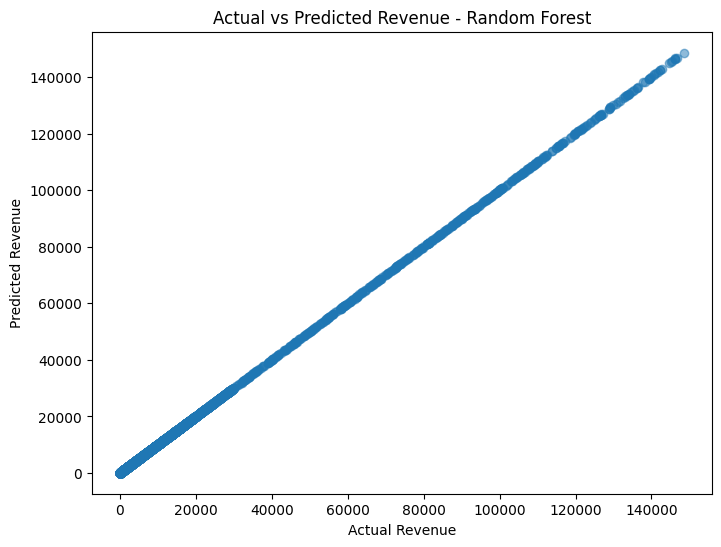

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title(
    f"Actual vs Predicted Revenue - {best_model_name}"
)

plt.show()

If the predictions are close to the diagonal pattern, the model is performing reasonably well.

20. Residual Analysis

In [47]:
residuals = y_test - predictions

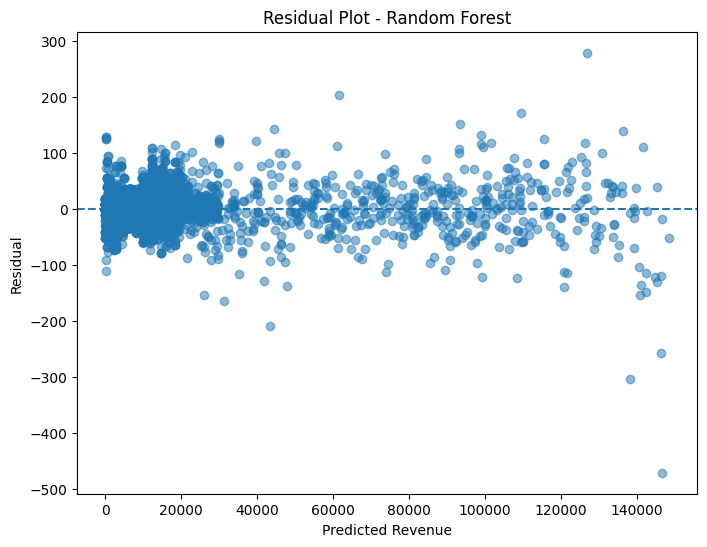

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residual")
plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.show()

A good regression model should have residuals reasonably scattered around zero without a strong systematic pattern.

21. Save the model results

In [48]:
comparison_df.to_csv(
    "Sprint_9_Model_Comparison.csv",
    index=False
)

test_results_df.to_csv(
    "Sprint_9_Test_Results.csv",
    index=False
)